<div align="center">

<img src="customersegmenation.jpg" width="300">

<div align="center">

<h1 style="color:red; font-weight:bold;">
Customer Segmentation Using Clustering Algorithms
</h1>

<<div align="center">
<h2 style="color:red;">
PROJECT WORKFLOW
</h2>
</div>
1. Business Understanding

   - Understand the business objective.
   - Segment customers to support targeted marketing strategies.
   - Analyze customer purchasing behavior using transactional data.

2. Data Collection
   - Import the dataset from CSV file using pandas.
   - Examine dataset structure, variables, and dimensions.

3. Data Understanding
   - Analyze data types, missing values, and duplicate records.
   - Explore customer, product, and order-related information.

4. Data Cleaning and Preprocessing
   - Remove columns with excessive missing values.
   - Handle remaining missing values using appropriate methods.
   - Remove unnecessary and constant-value features.
   - Convert date columns into datetime format.
   - Prepare clean data for analysis.

5. Data Preparation
   - Create three separate dataframes:
        • Customers
        • Products
        • Orders
   - Create TotalPrice feature using quantity and product price.

6. SQLite Database Operations
   - Create SQLite database connection.
   - Insert Customers, Products, and Orders tables into the database.
   - Use SQL JOIN queries to merge tables into a single dataframe.

7. Exploratory Data Analysis (EDA)
   - Analyze customer purchasing behavior.
   - Explore transaction distributions and spending patterns.
   - Examine RFM feature distributions.

8. RFM Analysis
   - Calculate:
        • Recency
        • Frequency
        • Monetary
   - Create RFM table for customer behavior analysis.

9. Feature Scaling
   - Standardize RFM features using StandardScaler.
   - Prepare data for clustering algorithms.

10. K-Means Clustering
   - Apply K-Means clustering algorithm.
   - Use Elbow Method to determine optimal cluster number.
   - Segment customers into meaningful groups.

11. Customer Segment Analysis
   - Analyze average RFM values for each segment.
   - Identify:
        • VIP Customers
        • Loyal Customers
        • Regular Customers
        • Potential Customers
        • Inactive Customers

12. Data Visualization
   - Visualize customer segments using:
        • Bar charts
        • Pie charts
        • RFM comparison graphs
        • Heatmaps

13. Results and Interpretation
   - Interpret customer segment characteristics.
   - Analyze customer purchasing behavior patterns.
   - Discuss business implications for targeted marketing strategies.

14. Conclusion
   - Summarize project findings.
   - Explain how customer segmentation can support personalized marketing and customer relationship management.

In [4]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
df = pd.read_csv("PBL5recommendationdata.csv", encoding="latin-1")
df.head(10)

C:\Users\zbeun\AppData\Local\Temp\ipykernel_13136\2382122747.py:6: DtypeWarning: Columns (20,33,73,106,158) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("PBL5recommendationdata.csv", encoding="latin-1")


,Customers.id,Customers.fname,Customers.lname,Customers.company,Customers.create_date,Customers.status,Customers.mailing,Customers.reminders,Customers.tax_exempt,Customers.account_id,...,Products.google_shopping_label,Products.product_option,Products.size,Products.material,Products.arm_style,Products.leg_style,Products.seat_size,Products.family_id,Products.saved_status,Products.freight_cost
0,797,Christy,Dill,Company0,1426018724,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PF61071,0.0,NaN
1,3,John,Smith,Company1,1386089139,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PF02132,NaN,NaN
2,3,John,Smith,Company1,1386089139,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2 x Extra large,Nitrile,NaN,NaN,NaN,PF00342,0.0,NaN
3,4,James,Anderson,NaN,1386780263,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PF04970,NaN,NaN
4,5,Abraham,Pollak,Company3,1386861599,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PF03045,NaN,NaN
5,5,Abraham,Pollak,Company3,1386861599,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,5,Abraham,Pollak,Company3,1386861599,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7,peggy,thompson,NaN,1388155947,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PF01527,0.0,NaN
8,8,Randy,Pruss,NaN,1389303216,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PF04706,0.0,NaN
9,10,Tommy,Smith,NaN,1390509516,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.tail(10)

,Customers.id,Customers.fname,Customers.lname,Customers.company,Customers.create_date,Customers.status,Customers.mailing,Customers.reminders,Customers.tax_exempt,Customers.account_id,...,Products.google_shopping_label,Products.product_option,Products.size,Products.material,Products.arm_style,Products.leg_style,Products.seat_size,Products.family_id,Products.saved_status,Products.freight_cost
4184,3726,Lisa,Mongar,NaN,1463368000,NaN,1.0,NaN,NaN,NaN,...,NaN,NaN,Medium,Nitrile,NaN,NaN,NaN,PF56141,0.0,NaN
4185,3728,Cheryl,Veglio,NaN,1463370416,NaN,NaN,NaN,NaN,NaN,...,NaN,"neck contour - 9"" x 24""",NaN,NaN,NaN,NaN,NaN,Fei-101,3.0,NaN
4186,3728,Cheryl,Veglio,NaN,1463370416,NaN,NaN,NaN,NaN,NaN,...,NaN,"knee - shoulder - Size - 10"" x 20""",NaN,NaN,NaN,NaN,NaN,Fei-101,3.0,NaN
4187,3728,Cheryl,Veglio,NaN,1463370416,NaN,NaN,NaN,NaN,NaN,...,NaN,"spine - Large - 10"" x 24""",NaN,NaN,NaN,NaN,NaN,Fei-101,3.0,NaN
4188,3729,Gloria,Suarez,Company425,1463405862,NaN,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PF04660,0.0,NaN
4189,3730,Nora,Fontana,NaN,1463408698,NaN,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,Plastic Rim,NaN,NaN,NaN,PF06157,3.0,NaN
4190,3732,Kennithe,Tecora,NaN,1463412756,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PF08485,3.0,NaN
4191,3733,Tinna,Randall,NaN,1463413245,NaN,NaN,NaN,NaN,NaN,...,NaN,21AH Batteries,NaN,NaN,NaN,NaN,NaN,PM36,3.0,NaN
4192,3735,HALIMAH,SHAHID,NaN,1463416687,NaN,1.0,NaN,NaN,NaN,...,5.0,NaN,NaN,Aluminum,NaN,NaN,NaN,PF04829,3.0,NaN
4193,3736,Michael,Kiernan,NaN,1463418049,NaN,1.0,NaN,NaN,NaN,...,NaN,NaN,Large,NaN,NaN,NaN,NaN,PF03816,3.0,NaN


In [2]:
df.shape

(4194, 181)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4194 entries, 0 to 4193
Columns: 181 entries, Customers.id to Products.freight_cost
dtypes: float64(98), int64(10), object(73)
memory usage: 5.8+ MB


In [4]:
df.columns


Index(['Customers.id', 'Customers.fname', 'Customers.lname',
       'Customers.company', 'Customers.create_date', 'Customers.status',
       'Customers.mailing', 'Customers.reminders', 'Customers.tax_exempt',
       'Customers.account_id',
       ...
       'Products.google_shopping_label', 'Products.product_option',
       'Products.size', 'Products.material', 'Products.arm_style',
       'Products.leg_style', 'Products.seat_size', 'Products.family_id',
       'Products.saved_status', 'Products.freight_cost'],
      dtype='object', length=181)

In [23]:
missing_df = pd.DataFrame({"Missing Values": df.isnull().sum(),"Percentage": (df.isnull().sum() / len(df)) * 100})
missing_df = missing_df[missing_df["Missing Values"] > 0]
missing_df.sort_values(by="Missing Values",ascending=False)

,Missing Values,Percentage
Products.freight_cost,4194,100.000000
Products.default_quantity,4194,100.000000
Products.audio,4194,100.000000
Orders.gift_message,4194,100.000000
Order_Items.related_id,4194,100.000000
...,...,...
Orders.updated_date,23,0.548402
Orders.payment_date,18,0.429185
Orders.payment_amount,18,0.429185
Orders.payment_status,5,0.119218


In [5]:
empty_cols = df.columns[df.isnull().mean() == 1]
df = df.drop(columns=empty_cols)
print(empty_cols)

Index(['Customers.reminders', 'Customers.sales_rep', 'Customers.rewards',
       'Customers.profile_id', 'Orders.sales_rep', 'Orders.gift_id',
       'Orders.gift_amount', 'Orders.shipping_trans', 'Orders.shipping_flags',
       'Orders.purchase_order', 'Orders.payment_ref', 'Orders.registry_id',
       'Orders.gift_message', 'Orders.website', 'Orders.mailing',
       'Order_Items.attributes', 'Order_Items.attribute_prices',
       'Order_Items.registry_item', 'Order_Items.related_id',
       'Order_Items.account_id', 'Products.product_type', 'Products.menu_name',
       'Products.right_flag', 'Products.amazon_type',
       'Products.google_adwords', 'Products.price_break_type',
       'Products.price_breaks', 'Products.websites', 'Products.audio',
       'Products.seo_footer', 'Products.markup', 'Products.default_quantity',
       'Products.leg_style', 'Products.freight_cost'],
      dtype='object')


In [6]:
empty_cols = df.columns[df.isnull().mean() == 1]
df = df.drop(columns=empty_cols)
print("Removed empty columns:", len(empty_cols))

Removed empty columns: 0


In [7]:
missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": df.isnull().mean() * 100})

missing_df = missing_df[missing_df["Missing Values"] > 0]

missing_df.sort_values("Percentage", ascending=False).head(30)

,Missing Values,Percentage
Orders.flags,4193,99.976156
Products.shopping_age,4192,99.952313
Products.features_title,4192,99.952313
Customers.account_id,4191,99.928469
Orders.weight,4191,99.928469
Customers.tax_exempt,4189,99.880782
Orders.external_id,4189,99.880782
Products.seo_header,4185,99.785408
Products.display_packaging,4178,99.618503
Order_Items.reorder_frequency,4170,99.427754


In [8]:
orders = df[[
    "Orders.id",
    "Orders.customer_id",
    "Orders.order_number",
    "Orders.total",
    "Orders.payment_status",
    "Orders.status",
    "Orders.placed_date",
    "Order_Items.product_id",
    "Order_Items.product_name",
    "Order_Items.qty",
    "Order_Items.price"]]

orders.head(10)

,Orders.id,Orders.customer_id,Orders.order_number,Orders.total,Orders.payment_status,Orders.status,Orders.placed_date,Order_Items.product_id,Order_Items.product_name,Order_Items.qty,Order_Items.price
0,3758,797,3758,64.29,3.0,1,1426019099,2310.0,"Basic Rollators, Green",1,57.20
1,23,3,23,29.99,3.0,1,1386090455,177.0,"Urinary Drain Bags,0.000",4,5.00
2,9531,3,9531,78.73,3.0,3,1449603652,1.0,"SensiCare Nitrile Exam Gloves, Blue, XX-Large",1,68.78
3,29,4,29,29.55,3.0,1,1386780263,983.0,Basket for 2-Button Walkers,1,19.56
4,30,5,30,46.00,3.0,1,1386861599,991.0,Tens Units,1,36.05
5,226,5,226,54.41,0.0,1,1394380527,310.0,"FitRight Ultra Protective Underwear, Large",1,44.46
6,1658,5,1658,24.58,3.0,1,1410363655,799.0,"SensiCare Silk Nitrile Exam Gloves, Dark Blue,...",1,14.63
7,32,7,32,49.14,3.0,1,1388155947,1379.0,Aloetouch Sensitive Personal Cleansing Baby Wipes,1,39.19
8,40,8,40,69.70,3.0,1,1389303216,815.0,Universal Raised Toilet Seat,1,59.75
9,70,10,70,34.00,3.0,1,1390509516,NaN,Drive medical excersize paddler item #RTL10273,1,34.00


In [9]:
high_missing_cols = df.columns[df.isnull().mean() > 0.80]
df = df.drop(columns=high_missing_cols)
print("Removed high missing columns:", len(high_missing_cols))

Removed high missing columns: 44


In [10]:
df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)

Orders.coupon_id          3312
Orders.coupon_amount      3312
Products.height           3198
Products.width            3198
Products.handling_time    3196
                          ... 
Orders.updated_date         23
Orders.payment_date         18
Orders.payment_amount       18
Orders.payment_status        5
Order_Items.cost             3
Length: 83, dtype: int64

In [11]:
missing_percent = (df.isnull().mean() * 100)

high_missing_cols = missing_percent[
    missing_percent > 60].index

df = df.drop(
    columns=high_missing_cols)

print("Removed Columns:",
    len(high_missing_cols))

Removed Columns: 15


In [12]:
df.isnull().sum()[
    df.isnull().sum() > 0
].sort_values(ascending=False)

Products.shopping_color    2494
Products.latex             2255
Products.hygienic          2114
Customers.mailing          2080
Products.upc               2067
                           ... 
Orders.updated_date          23
Orders.payment_amount        18
Orders.payment_date          18
Orders.payment_status         5
Order_Items.cost              3
Length: 68, dtype: int64

In [13]:
drop_cols = [
    "Products.shopping_color",
    "Products.latex",
    "Products.hygienic",
    "Products.upc"]

df = df.drop(
    columns=drop_cols,
    errors="ignore")

In [14]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

In [15]:
object_cols = df.select_dtypes(    include="object").columns
for col in object_cols:
    df[col] = df[col].fillna(
        df[col].mode()[0]    )

In [16]:
df.isnull().sum().sum()

np.int64(0)

In [17]:
### Customers,Products,Orders tablolarını olustur

In [19]:
[col for col in df.columns if "Customers." in col]

['Customers.id',
 'Customers.fname',
 'Customers.lname',
 'Customers.create_date',
 'Customers.mailing',
 'Customers.last_modified',
 'Customers.customer_type']

In [21]:
customers = df[[
    "Customers.id",
    "Customers.fname",
    "Customers.lname",
    "Customers.create_date",
    "Customers.mailing",
    "Customers.customer_type"]].drop_duplicates()

customers.head(20)

,Customers.id,Customers.fname,Customers.lname,Customers.create_date,Customers.mailing,Customers.customer_type
0,797,Christy,Dill,1426018724,0.979659,0.0
1,3,John,Smith,1386089139,0.979659,0.0
3,4,James,Anderson,1386780263,0.979659,0.0
4,5,Abraham,Pollak,1386861599,0.000000,0.0
7,7,peggy,thompson,1388155947,0.979659,0.0
8,8,Randy,Pruss,1389303216,0.979659,0.0
9,10,Tommy,Smith,1390509516,0.979659,0.0
10,11,Mark,Tremble,1390573155,0.979659,0.0
11,12,Emely,Cooke,1390613314,0.979659,0.0
12,13,george,mcmillin,1390856039,0.979659,0.0


In [22]:
customers = df[[
    "Customers.id",
    "Customers.fname",
    "Customers.lname",
    "Customers.create_date",
    "Customers.mailing"
]].drop_duplicates()

customers.head(20)

,Customers.id,Customers.fname,Customers.lname,Customers.create_date,Customers.mailing
0,797,Christy,Dill,1426018724,0.979659
1,3,John,Smith,1386089139,0.979659
3,4,James,Anderson,1386780263,0.979659
4,5,Abraham,Pollak,1386861599,0.000000
7,7,peggy,thompson,1388155947,0.979659
8,8,Randy,Pruss,1389303216,0.979659
9,10,Tommy,Smith,1390509516,0.979659
10,11,Mark,Tremble,1390573155,0.979659
11,12,Emely,Cooke,1390613314,0.979659
12,13,george,mcmillin,1390856039,0.979659


In [23]:
import sqlite3

conn = sqlite3.connect(
    "customer_segmentation.db")

In [24]:
customers.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False)

3054

In [26]:
products = df[[
    "Products.id",
    "Products.name",
    "Products.price"
]].drop_duplicates()

products.head()

,Products.id,Products.name,Products.price
0,2310.0,"Basic Steel Rollators,Green",57.64
1,177.0,Urinary Drain Bags,10.29
2,1.0,"SensiCare Nitrile Exam Gloves,Blue,XX-Large",68.78
3,983.0,Basket for 2-Button Walkers,19.56
4,991.0,TENS 3000 Analog Unit,36.05


In [27]:
products.to_sql(
    "products",
    conn,
    if_exists="replace",
    index=False
)

1711

In [28]:
query = """

SELECT

    o.*,

    p."Products.name",
    p."Products.price",

    c."Customers.fname",
    c."Customers.lname"

FROM orders o

LEFT JOIN products p
ON o."Order_Items.product_id" = p."Products.id"

LEFT JOIN customers c
ON o."Orders.customer_id" = c."Customers.id"

"""

In [29]:
merged_df = pd.read_sql(
    query,
    conn)

merged_df.head()

,Orders.id,Orders.customer_id,Orders.order_number,Orders.total,Orders.payment_status,Orders.status,Orders.placed_date,Order_Items.product_id,Order_Items.product_name,Order_Items.qty,Order_Items.price,Products.name,Products.price,Customers.fname,Customers.lname
0,3758,797,3758,64.29,3.0,1,1426019099,2310.0,"Basic Rollators, Green",1,57.20,"Basic Steel Rollators,Green",57.64,Christy,Dill
1,23,3,23,29.99,3.0,1,1386090455,177.0,"Urinary Drain Bags,0.000",4,5.00,Urinary Drain Bags,10.29,John,Smith
2,9531,3,9531,78.73,3.0,3,1449603652,1.0,"SensiCare Nitrile Exam Gloves, Blue, XX-Large",1,68.78,"SensiCare Nitrile Exam Gloves,Blue,XX-Large",68.78,John,Smith
3,29,4,29,29.55,3.0,1,1386780263,983.0,Basket for 2-Button Walkers,1,19.56,Basket for 2-Button Walkers,19.56,James,Anderson
4,30,5,30,46.00,3.0,1,1386861599,991.0,Tens Units,1,36.05,TENS 3000 Analog Unit,36.05,Abraham,Pollak


In [30]:
merged_df.shape

(4194, 15)

In [31]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4194 entries, 0 to 4193
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Orders.id                 4194 non-null   int64  
 1   Orders.customer_id        4194 non-null   int64  
 2   Orders.order_number       4194 non-null   object 
 3   Orders.total              4194 non-null   float64
 4   Orders.payment_status     4189 non-null   float64
 5   Orders.status             4194 non-null   int64  
 6   Orders.placed_date        4194 non-null   int64  
 7   Order_Items.product_id    4151 non-null   float64
 8   Order_Items.product_name  4194 non-null   object 
 9   Order_Items.qty           4194 non-null   int64  
 10  Order_Items.price         4194 non-null   float64
 11  Products.name             4037 non-null   object 
 12  Products.price            4037 non-null   float64
 13  Customers.fname           4194 non-null   object 
 14  Customer

In [32]:
merged_df["Orders.placed_date"] = pd.to_datetime(
    merged_df["Orders.placed_date"],
    errors="coerce")

In [33]:
merged_df.isnull().sum()

Orders.id                     0
Orders.customer_id            0
Orders.order_number           0
Orders.total                  0
Orders.payment_status         5
Orders.status                 0
Orders.placed_date            0
Order_Items.product_id       43
Order_Items.product_name      0
Order_Items.qty               0
Order_Items.price             0
Products.name               157
Products.price              157
Customers.fname               0
Customers.lname               0
dtype: int64

In [37]:
merged_df = merged_df.dropna(
    subset=[
        "Order_Items.product_id",
        "Products.name",
        "Products.price",
        "Orders.payment_status"])

In [38]:
merged_df.isnull().sum()

Orders.id                   0
Orders.customer_id          0
Orders.order_number         0
Orders.total                0
Orders.payment_status       0
Orders.status               0
Orders.placed_date          0
Order_Items.product_id      0
Order_Items.product_name    0
Order_Items.qty             0
Order_Items.price           0
Products.name               0
Products.price              0
Customers.fname             0
Customers.lname             0
TotalPrice                  0
dtype: int64

In [36]:
merged_df.head()

,Orders.id,Orders.customer_id,Orders.order_number,Orders.total,Orders.payment_status,Orders.status,Orders.placed_date,Order_Items.product_id,Order_Items.product_name,Order_Items.qty,Order_Items.price,Products.name,Products.price,Customers.fname,Customers.lname,TotalPrice
0,3758,797,3758,64.29,3.0,1,1970-01-01 00:00:01.426019099,2310.0,"Basic Rollators, Green",1,57.20,"Basic Steel Rollators,Green",57.64,Christy,Dill,57.20
1,23,3,23,29.99,3.0,1,1970-01-01 00:00:01.386090455,177.0,"Urinary Drain Bags,0.000",4,5.00,Urinary Drain Bags,10.29,John,Smith,20.00
2,9531,3,9531,78.73,3.0,3,1970-01-01 00:00:01.449603652,1.0,"SensiCare Nitrile Exam Gloves, Blue, XX-Large",1,68.78,"SensiCare Nitrile Exam Gloves,Blue,XX-Large",68.78,John,Smith,68.78
3,29,4,29,29.55,3.0,1,1970-01-01 00:00:01.386780263,983.0,Basket for 2-Button Walkers,1,19.56,Basket for 2-Button Walkers,19.56,James,Anderson,19.56
4,30,5,30,46.00,3.0,1,1970-01-01 00:00:01.386861599,991.0,Tens Units,1,36.05,TENS 3000 Analog Unit,36.05,Abraham,Pollak,36.05


In [39]:
merged_df.isnull().sum()

Orders.id                   0
Orders.customer_id          0
Orders.order_number         0
Orders.total                0
Orders.payment_status       0
Orders.status               0
Orders.placed_date          0
Order_Items.product_id      0
Order_Items.product_name    0
Order_Items.qty             0
Order_Items.price           0
Products.name               0
Products.price              0
Customers.fname             0
Customers.lname             0
TotalPrice                  0
dtype: int64

In [40]:
merged_df["TotalPrice"] = (
    merged_df["Order_Items.qty"] *
    merged_df["Order_Items.price"])

In [41]:
merged_df[[
    "Order_Items.qty",
    "Order_Items.price",
    "TotalPrice"
]].head()

,Order_Items.qty,Order_Items.price,TotalPrice
0,1,57.20,57.20
1,4,5.00,20.00
2,1,68.78,68.78
3,1,19.56,19.56
4,1,36.05,36.05


### RFM Analysis 

In [42]:
import datetime as dt

now = merged_df[
    "Orders.placed_date"
].max()

now

Timestamp('1970-01-01 00:00:01.463418879')

In [43]:
merged_df["Orders.placed_date"].head()

0   1970-01-01 00:00:01.426019099
1   1970-01-01 00:00:01.386090455
2   1970-01-01 00:00:01.449603652
3   1970-01-01 00:00:01.386780263
4   1970-01-01 00:00:01.386861599
Name: Orders.placed_date, dtype: datetime64[ns]

In [44]:
merged_df["Orders.placed_date"].dtype

dtype('<M8[ns]')

In [45]:
merged_df["Orders.placed_date"].head(10)

0    1970-01-01 00:00:01.426019099
1    1970-01-01 00:00:01.386090455
2    1970-01-01 00:00:01.449603652
3    1970-01-01 00:00:01.386780263
4    1970-01-01 00:00:01.386861599
7    1970-01-01 00:00:01.388155947
8    1970-01-01 00:00:01.389303216
11   1970-01-01 00:00:01.390613419
12   1970-01-01 00:00:01.390856041
13   1970-01-01 00:00:01.390856041
Name: Orders.placed_date, dtype: datetime64[ns]

In [46]:
merged_df = pd.read_sql(query, conn)

merged_df["Orders.placed_date"] = pd.to_datetime(
    merged_df["Orders.placed_date"],
    unit="s",
    errors="coerce"
)

merged_df["Orders.placed_date"].head()

0   2015-03-10 20:24:59
1   2013-12-03 17:07:35
2   2015-12-08 19:40:52
3   2013-12-11 16:44:23
4   2013-12-12 15:19:59
Name: Orders.placed_date, dtype: datetime64[ns]

In [47]:
merged_df = merged_df.dropna(
    subset=[
        "Order_Items.product_id",
        "Products.name",
        "Products.price",
        "Orders.payment_status",
        "Orders.placed_date"])

In [48]:
merged_df["TotalPrice"] = (
    merged_df["Order_Items.qty"] *
    merged_df["Order_Items.price"])

In [49]:
import datetime as dt

now = merged_df[
    "Orders.placed_date"
].max()

print(now)

2016-05-16 17:14:39


In [50]:
recency = (
    now -
    merged_df.groupby(
        "Orders.customer_id"
    )["Orders.placed_date"].max()).dt.days

In [51]:
frequency = (
    merged_df.groupby(
        "Orders.customer_id"
    )["Orders.id"]
    .nunique())

In [52]:
monetary = (
    merged_df.groupby(
        "Orders.customer_id"
    )["TotalPrice"]
    .sum())

In [53]:
rfm = pd.DataFrame({
    "Recency": recency,
    "Frequency": frequency,
    "Monetary": monetary})
rfm.head()

,Recency,Frequency,Monetary
Orders.customer_id,,,
3,159,2,88.78
4,887,1,19.56
5,886,1,36.05
7,871,1,39.19
8,857,1,59.75


In [54]:
rfm.describe()

,Recency,Frequency,Monetary
count,2960.000000,2960.000000,2960.000000
mean,226.878378,1.159797,125.751720
std,211.051516,0.915382,338.179404
min,0.000000,1.000000,2.890000
25%,56.000000,1.000000,30.995000
50%,142.000000,1.000000,61.570000
75%,358.500000,1.000000,124.740000
max,887.000000,18.000000,10383.000000


### CLUSTERING

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)


In [56]:
rfm_scaled[:5]

array([[-0.32167429,  0.91802655, -0.10934423],
       [ 3.12830332, -0.17459854, -0.31406307],
       [ 3.12356434, -0.17459854, -0.26529373],
       [ 3.05247964, -0.17459854, -0.25600715],
       [ 2.98613391, -0.17459854, -0.19520074]])

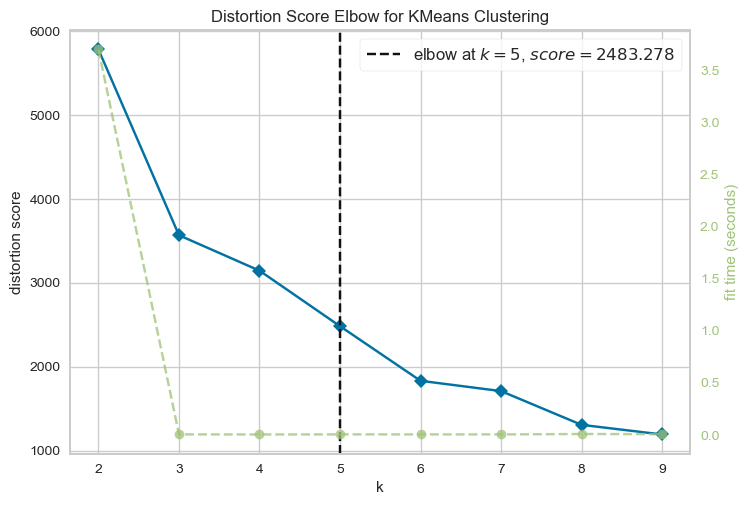

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [57]:
###ELBOW METHOD
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(random_state=42)

visualizer = KElbowVisualizer(
    model,
    k=(2,10))

visualizer.fit(rfm_scaled)

visualizer.show()

#### The Elbow Method was applied to determine the optimal number of customer segments. According to the distortion score graph, the elbow point occurred at k=5. Therefore, the number of clusters was selected as 5 for the K-Means clustering model.

In [58]:
### K MEANS
kmeans = KMeans(
    n_clusters=5,
    random_state=42)

rfm["Cluster"] = kmeans.fit_predict(
    rfm_scaled)

In [59]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
Orders.customer_id,,,,
3,159,2,88.78,3
4,887,1,19.56,2
5,886,1,36.05,2
7,871,1,39.19,2
8,857,1,59.75,2


In [60]:
rfm["Cluster"].value_counts()

Cluster
3    1660
0     771
2     443
4      73
1      13
Name: count, dtype: int64

In [61]:
rfm.groupby("Cluster").mean()

,Recency,Frequency,Monetary
Cluster,,,
0,332.870298,1.042802,97.780493
1,81.538462,11.153846,3538.006923
2,620.758465,1.038375,100.841354
3,76.362651,1.056024,88.987211
4,165.739726,3.712329,800.695205


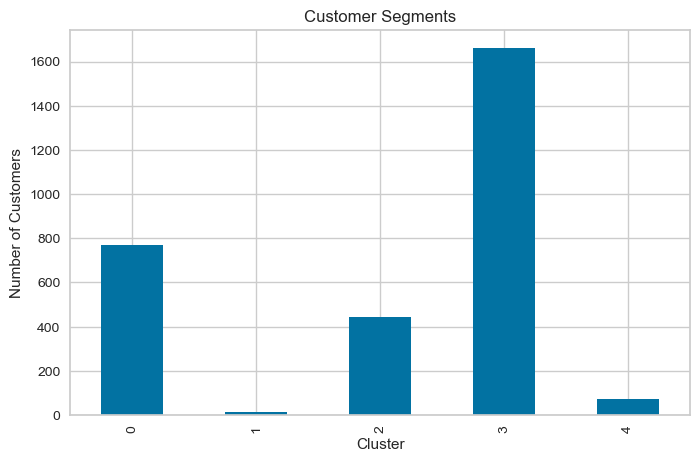

In [62]:
plt.figure(figsize=(8,5))

rfm["Cluster"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Customer Segments")

plt.xlabel("Cluster")

plt.ylabel("Number of Customers")

plt.show()

In [63]:
cluster_names = {
    0: "VIP Customers",
    1: "Loyal Customers",
    2: "Inactive Customers",
    3: "Regular Customers",
    4: "Potential Customers"
}

rfm["Segment"] = rfm["Cluster"].map(cluster_names)

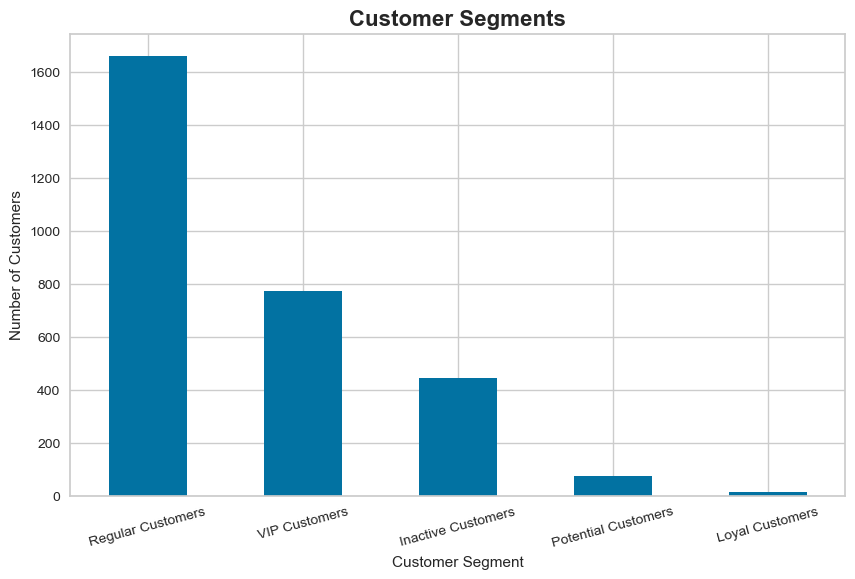

In [64]:
plt.figure(figsize=(10,6))

rfm["Segment"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Customer Segments",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

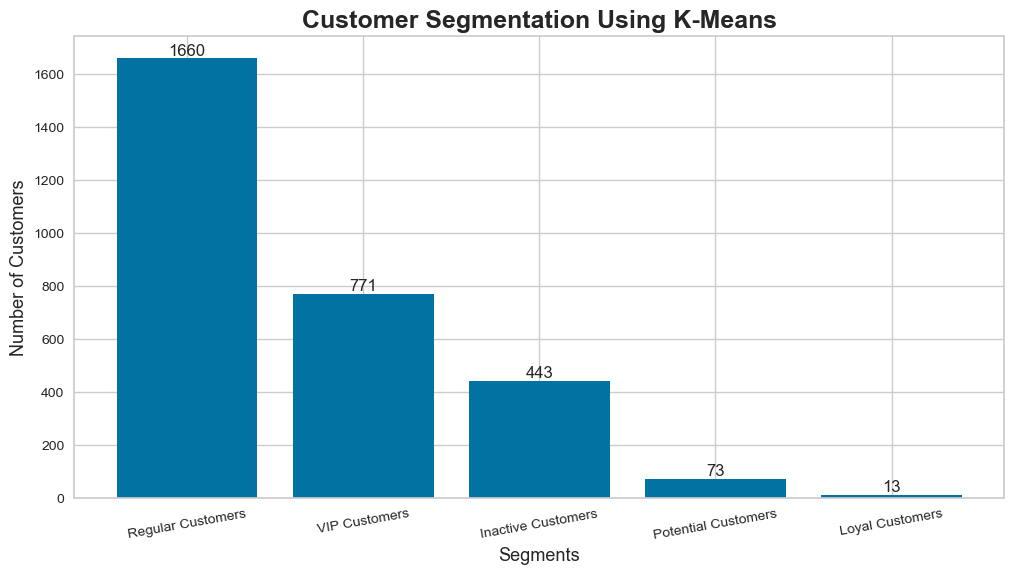

In [65]:
segment_counts = rfm["Segment"].value_counts()

plt.figure(figsize=(12,6))

bars = plt.bar(
    segment_counts.index,
    segment_counts.values)

plt.title(
    "Customer Segmentation Using K-Means",
    fontsize=18,
    fontweight="bold")

plt.xlabel("Segments", fontsize=13)
plt.ylabel("Number of Customers", fontsize=13)

plt.xticks(rotation=10)

# Sayıları yazdır
for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 10,
        int(yval),
        ha='center')

plt.show()

In [66]:
segment_summary = rfm.groupby("Segment")[[
    "Recency",
    "Frequency",
    "Monetary"
]].mean().round(2)

segment_summary

,Recency,Frequency,Monetary
Segment,,,
Inactive Customers,620.76,1.04,100.84
Loyal Customers,81.54,11.15,3538.01
Potential Customers,165.74,3.71,800.70
Regular Customers,76.36,1.06,88.99
VIP Customers,332.87,1.04,97.78


In [67]:
segment_summary = segment_summary.loc[[
        "VIP Customers",
        "Loyal Customers",
        "Potential Customers",
        "Regular Customers",
        "Inactive Customers"]]

segment_summary

,Recency,Frequency,Monetary
Segment,,,
VIP Customers,332.87,1.04,97.78
Loyal Customers,81.54,11.15,3538.01
Potential Customers,165.74,3.71,800.70
Regular Customers,76.36,1.06,88.99
Inactive Customers,620.76,1.04,100.84


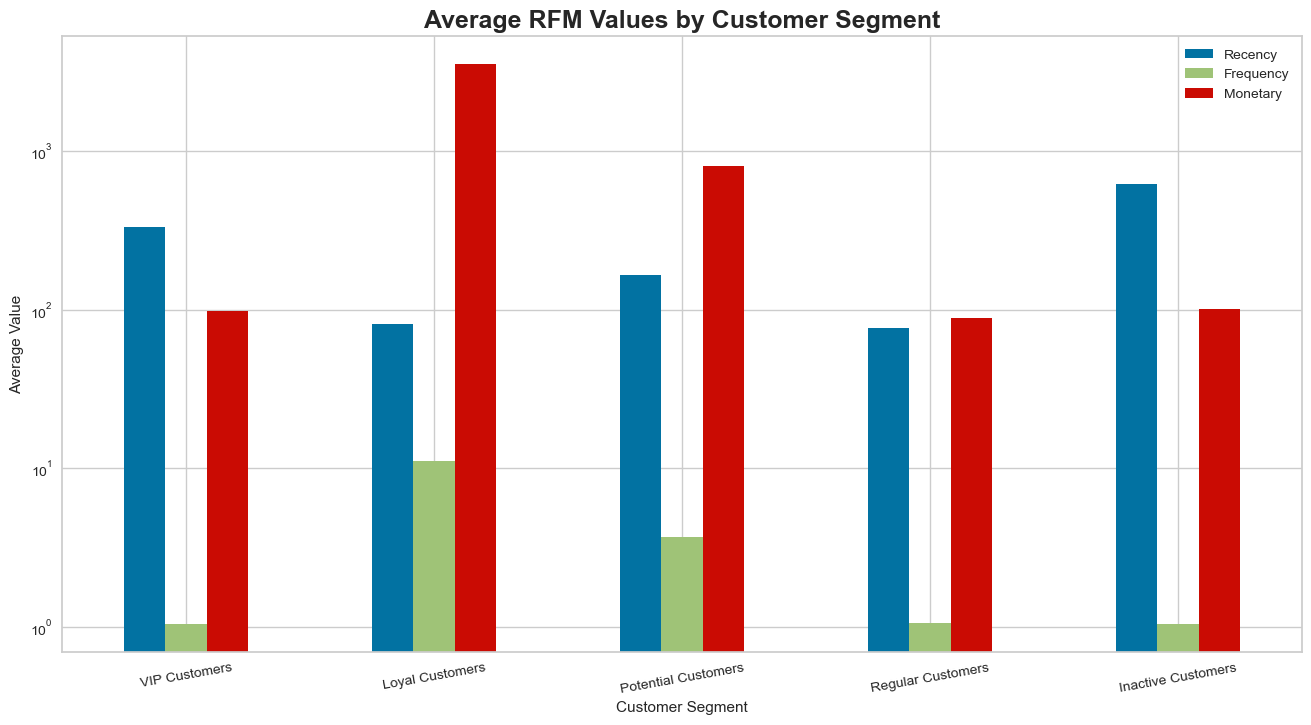

In [78]:
segment_summary.plot(
    kind="bar",
    figsize=(16,8))

plt.title(
    "Average RFM Values by Customer Segment",
    fontsize=18,
    fontweight="bold")

plt.xlabel("Customer Segment")
plt.ylabel("Average Value")

plt.xticks(rotation=10)
plt.yscale("log")

plt.show()

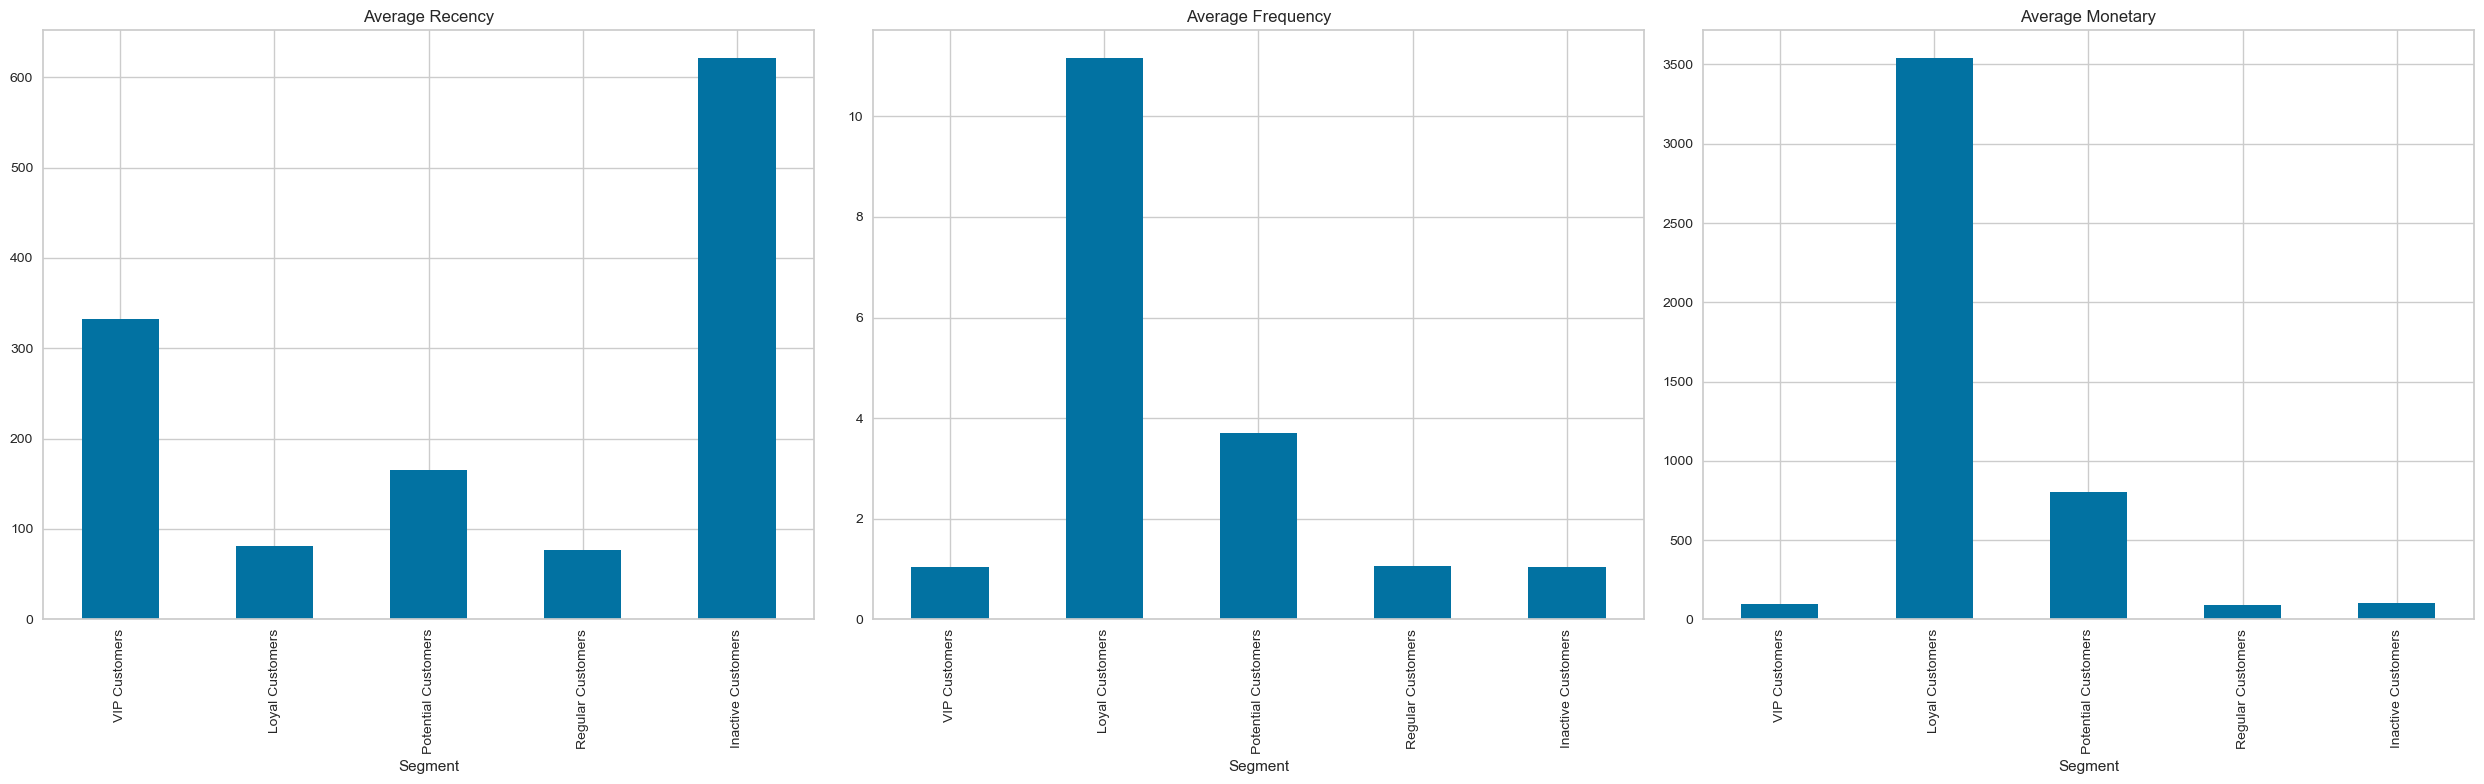

In [77]:
fig, axes = plt.subplots(1,3, figsize=(25,8))

# Recency
segment_summary["Recency"].plot(
    kind="bar",
    ax=axes[0])

axes[0].set_title("Average Recency")

# Frequency
segment_summary["Frequency"].plot(kind="bar",ax=axes[1])

axes[1].set_title("Average Frequency")

# Monetary
segment_summary["Monetary"].plot(kind="bar",ax=axes[2])

axes[2].set_title("Average Monetary")

plt.tight_layout()

plt.show()

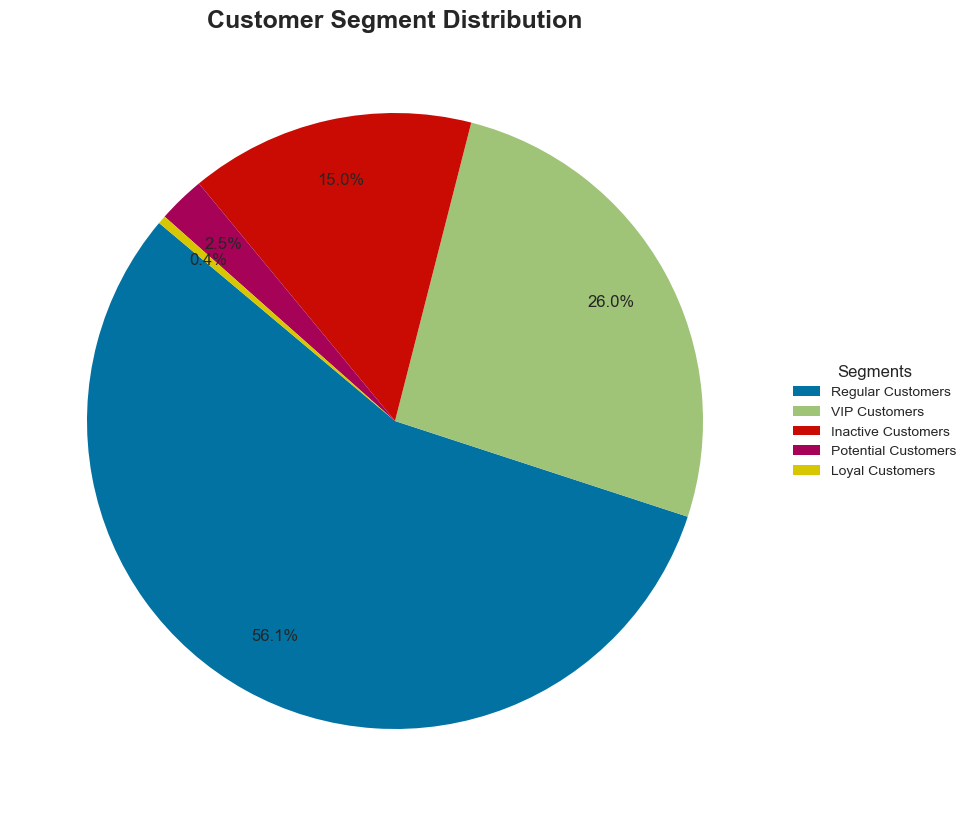

In [81]:
segment_counts = rfm["Segment"].value_counts()

plt.figure(figsize=(10,10))

wedges, texts, autotexts = plt.pie(
    segment_counts.values,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8)

plt.legend(
    wedges,
    segment_counts.index,
    title="Segments",
    loc="center left",
    bbox_to_anchor=(1, 0.5))

plt.title(
    "Customer Segment Distribution",
    fontsize=18,
    fontweight="bold")

plt.show()

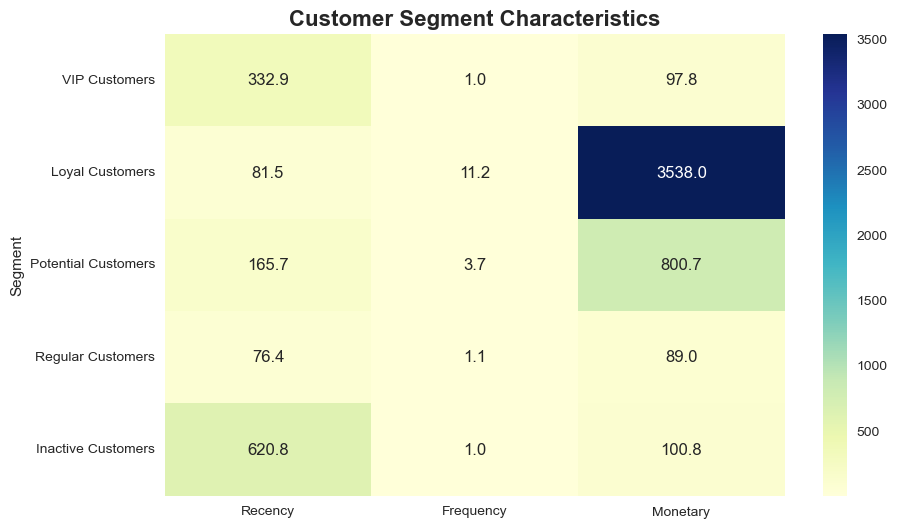

In [84]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(segment_summary,annot=True, cmap="YlGnBu",fmt=".1f")
plt.title("Customer Segment Characteristics",fontsize=16,fontweight="bold")
plt.show()

### Loyal Customers have the highest Frequency and Monetary values. These customers purchase frequently and spend significantly more money than other customer groups. They represent the most valuable customer segment for the company.
### VIP Customers have relatively high monetary value and moderate recency levels. Although they do not purchase very frequently, they still contribute important revenue to the business.
### Potential Customers show moderate frequency and spending behavior. These customers may become loyal customers with effective marketing campaigns and personalized offers.
### Regular Customers represent the largest customer group with average purchasing behavior. They purchase occasionally and generate moderate revenue for the company.
### Inactive Customers have the highest Recency values, meaning they have not purchased for a long time. Their low frequency and spending values indicate weak engagement with the company.
### The clustering results demonstrate that customer segmentation can successfully identify different purchasing behaviors. Businesses can use these insights to develop personalized marketing strategies, improve customer retention, and increase overall profitability.
### Heatmap grafiği müşteri segmentleri arasındaki davranış farklılıklarını açık bir şekilde göstermektedir. Grafiğe göre Loyal Customers grubu en yüksek Frequency ve Monetary değerlerine sahip olduğu için şirkete en fazla gelir sağlayan ve en sık alışveriş yapan sadık müşteri grubunu temsil etmektedir. VIP Customers grubu ise yüksek harcama potansiyeline sahip önemli müşterilerden oluşmaktadır. Bu müşterilerin Frequency değerleri düşük olmasına rağmen Monetary değerleri oldukça yüksektir; yani daha az sıklıkta alışveriş yapmalarına rağmen yüksek tutarlı harcamalar gerçekleştirmektedirler. Potential Customers grubu orta seviyede Frequency ve Monetary değerlerine sahip olup doğru pazarlama stratejileriyle sadık müşterilere dönüşme potansiyeli taşımaktadır. Regular Customers şirketin en geniş müşteri kitlesini oluşturmaktadır ve düzenli fakat düşük-orta seviyede harcama davranışı göstermektedir. Inactive Customers grubunda ise Recency değeri oldukça yüksek olduğu için uzun süredir alışveriş yapmayan müşteriler bulunmaktadır. Genel olarak bu segmentasyon analizi, müşteri davranışlarının daha iyi anlaşılmasına yardımcı olmakta ve hedef odaklı pazarlama stratejileri geliştirilmesi açısından önemli bilgiler sunmaktadır.

### In this project, I learned:

- Data preprocessing and cleaning
- Handling missing values
- Creating relational database structures using SQLite
- SQL table merging operations
- RFM analysis
- Feature scaling
- K-Means clustering
- Elbow Method
- Customer segmentation analysis
- Data visualization techniques

### FINAL CONCLUSION:
In this project, customer segmentation analysis was performed using RFM analysis and K-Means clustering. The dataset was cleaned and organized into Customers, Products, and Orders tables. These tables were stored in a SQLite database and merged using SQL queries.

RFM metrics were calculated to evaluate customer purchasing behavior based on recency, frequency, and monetary value. After scaling the RFM features, the optimal number of clusters was determined using the Elbow Method. Customers were successfully segmented into five meaningful groups such as VIP Customers, Loyal Customers, Regular Customers, Potential Customers, and Inactive Customers.

The results demonstrated how clustering techniques can help businesses better understand customer behavior and support targeted marketing strategies.